<a href="https://colab.research.google.com/github/maddygoodro/MIS433/blob/main/433_Bookselling_Tool_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BookIQ — Amazon Kindle Sales Analyst & Reader Recommender

**Dataset:** Amazon Kindle Books (October 2023, ~130K titles)  
**External API:** Google Books API (live metadata & cover images)  
**AI API:** OpenAI GPT-4o (market narratives, recommendations, pitch copy)  

---

### Project Features
| Feature | Description |
|---|---|
| 1 — Market Trend Explorer | Analyze a category: pricing, ratings, bestseller rates + AI market brief |
| 2 — Smart Book Finder | Search by keyword/genre → ranked results with live Google Books data + AI blurb |
| 3 — AI Book Pitch Generator | Enter a title → AI writes a marketing pitch grounded in real sales data |

---
## ⚙️ Setup & Imports

In [1]:
# Run this cell first in Colab to install any missing packages
#!pip install openai pandas matplotlib seaborn requests --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import requests
import json
import math
from IPython.display import display, Image, Markdown
from openai import OpenAI

# ── Plot style ──────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (9, 4)})

In [3]:
# API Keys
from google.colab import userdata

api_key = userdata.get('OPENAI_API_KEY')
from openai import OpenAI
client = OpenAI(api_key=api_key)
GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')


---
## 📂 Load & Preview Dataset

In [4]:
# ── Load the Kindle dataset ───────────────────────────────────────
# Update the path to wherever your CSV lives (Colab: upload or mount Drive)

from google.colab import drive

drive.mount('/content/drive')

kindle_data = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Data/kindle_data-v2.csv')
kindle_data.info()


#DATA_PATH = 'kindle_books.csv'   # TODO: update this path

Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133102 entries, 0 to 133101
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   asin               133102 non-null  object 
 1   title              133102 non-null  object 
 2   author             132677 non-null  object 
 3   soldBy             123869 non-null  object 
 4   imgUrl             133102 non-null  object 
 5   productURL         133102 non-null  object 
 6   stars              133102 non-null  float64
 7   reviews            133102 non-null  int64  
 8   price              133102 non-null  float64
 9   isKindleUnlimited  133102 non-null  bool   
 10  category_id        133102 non-null  int64  
 11  isBestSeller       133102 non-null  bool   
 12  isEditorsPick      133102 non-null  bool   
 13  isGoodReadsChoice  133102 non-null  bool   
 14  publishedDate      84086 non-null   object 
 15  category_name      133102

In [5]:
# ── Data cleaning ────────────────────────────────────────────────
kindle_data['stars']   = pd.to_numeric(kindle_data['stars'],   errors='coerce')
kindle_data['reviews'] = pd.to_numeric(kindle_data['reviews'], errors='coerce')
kindle_data['price']   = pd.to_numeric(kindle_data['price'],   errors='coerce')

# Boolean flags: normalize any mix of True/False/1/0/'true'/'false'
bool_cols = ['iskindleunlimited', 'isBestSeller', 'isEditorsPick', 'isGoodReadsChoice']
for col in bool_cols:
    if col in kindle_data.columns:
        kindle_data[col] = kindle_data[col].astype(str).str.lower().isin(['true', '1', 'yes'])

# Drop rows with no title or category
kindle_data = kindle_data.dropna(subset=['title', 'category_name'])

# Composite score: weighted quality signal used in Feature 2
kindle_data['score'] = kindle_data['stars'].fillna(0) * kindle_data['reviews'].fillna(0).apply(
    lambda r: math.log1p(r)  # log-scale reviews so prolific books don't dominate
)

print(f'Clean rows: {len(kindle_data):,}')
print(f'Categories: {kindle_data["category_name"].nunique()}')
kindle_data.describe()

Clean rows: 133,102
Categories: 31


,stars,reviews,price,category_id,score
count,133102.000000,133102.000000,133102.000000,133102.000000,133102.000000
mean,4.404090,887.375779,15.134127,16.287111,13.277614
std,0.745646,5104.878777,22.254986,8.416924,14.462387
min,0.000000,0.000000,0.000000,1.000000,0.000000
25%,4.400000,0.000000,4.990000,9.000000,0.000000
50%,4.500000,4.000000,9.990000,16.000000,6.931472
75%,4.700000,365.000000,14.990000,23.000000,26.591420
max,5.000000,618227.000000,682.000000,31.000000,62.672679


---
## 🔍 Exploratory Data Analysis
Quick insights before diving into the features.

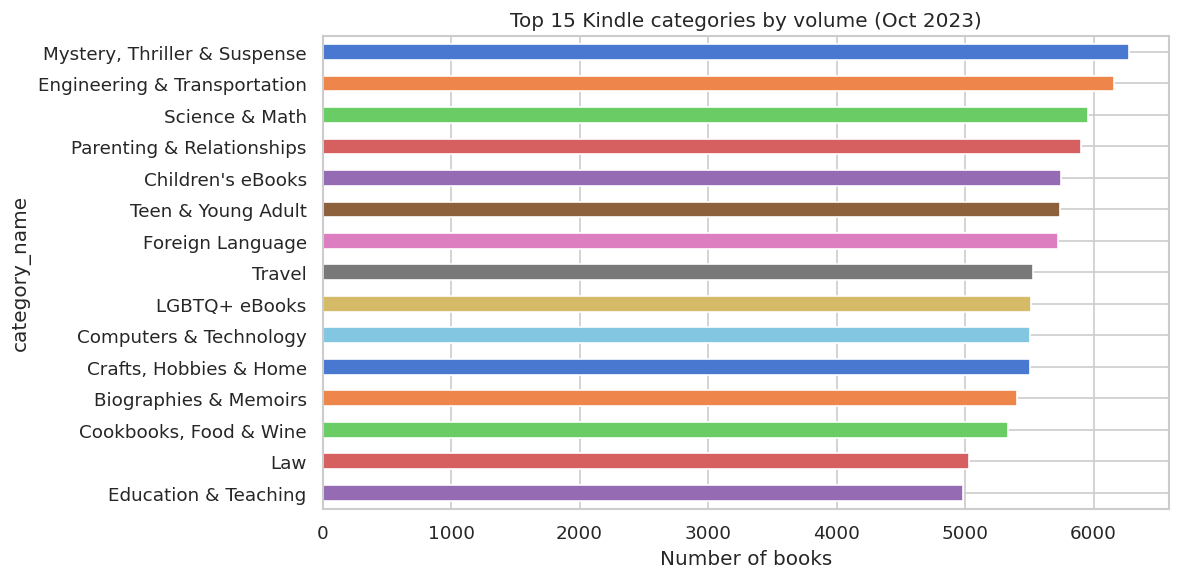

In [6]:
# Top 15 categories by volume
top_cats = kindle_data['category_name'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
top_cats.plot(kind='barh', ax=ax, color=sns.color_palette('muted', 15))
ax.set_xlabel('Number of books')
ax.set_title('Top 15 Kindle categories by volume (Oct 2023)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

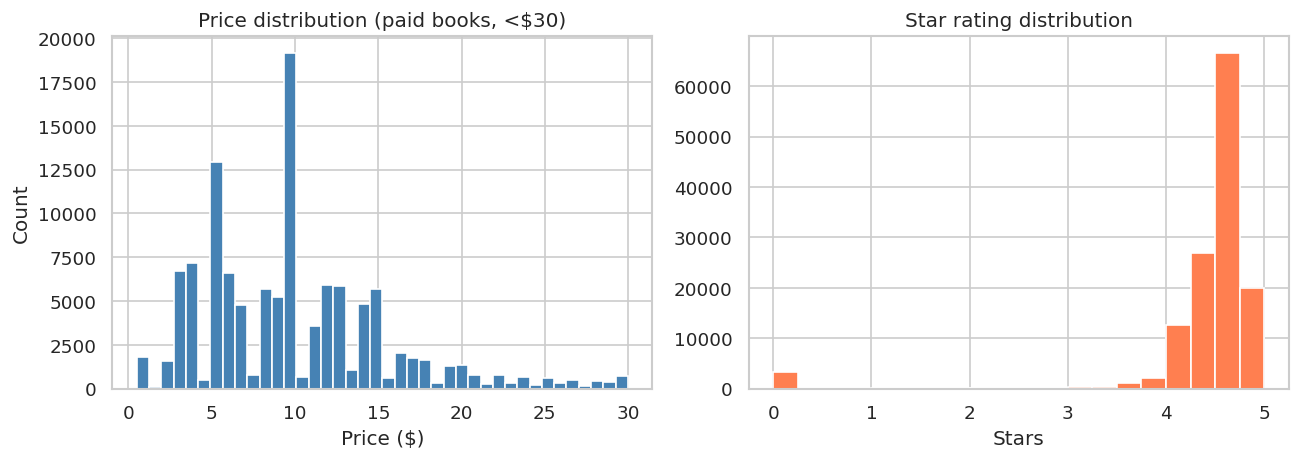

In [7]:
#Price distribution (exclude free / outliers)
paid = kindle_data[(kindle_data['price'] > 0) & (kindle_data['price'] < 30)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(paid['price'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Price distribution (paid books, <$30)')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')

axes[1].hist(kindle_data['stars'].dropna(), bins=20, color='coral', edgecolor='white')
axes[1].set_title('Star rating distribution')
axes[1].set_xlabel('Stars')

plt.tight_layout()
plt.show()

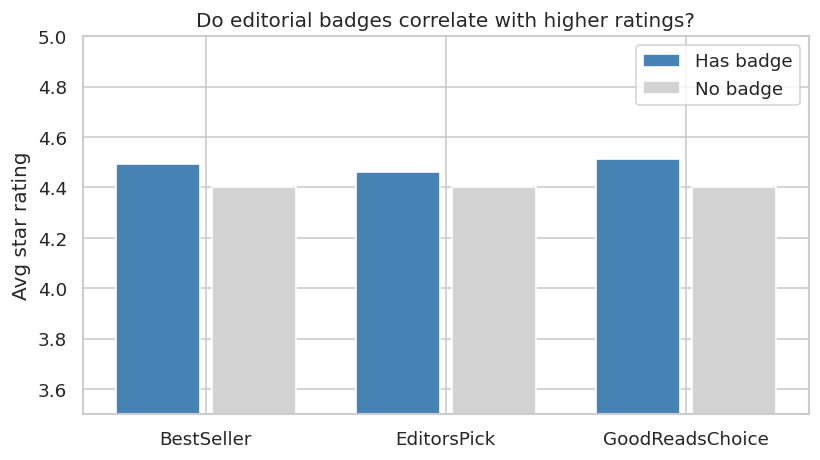

isBestSeller               with badge: 4.49  |  without: 4.40
isEditorsPick              with badge: 4.46  |  without: 4.40
isGoodReadsChoice          with badge: 4.51  |  without: 4.40


In [8]:
# Do badges (EditorsPick, GoodReads) affect ratings?
badge_cols = [c for c in ['isBestSeller','isEditorsPick','isGoodReadsChoice'] if c in kindle_data.columns]
badge_means = {col: (kindle_data[kindle_data[col]]['stars'].mean(), kindle_data[~kindle_data[col]]['stars'].mean())
               for col in badge_cols}

labels   = [c.replace('is','') for c in badge_cols]
with_badge    = [badge_means[c][0] for c in badge_cols]
without_badge = [badge_means[c][1] for c in badge_cols]

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - 0.2, with_badge,    0.35, label='Has badge',    color='steelblue')
ax.bar(x + 0.2, without_badge, 0.35, label='No badge',     color='lightgray')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(3.5, 5.0)
ax.set_ylabel('Avg star rating')
ax.set_title('Do editorial badges correlate with higher ratings?')
ax.legend()
plt.tight_layout()
plt.show()

for col, (w, wo) in badge_means.items():
    print(f'{col:25s}  with badge: {w:.2f}  |  without: {wo:.2f}')

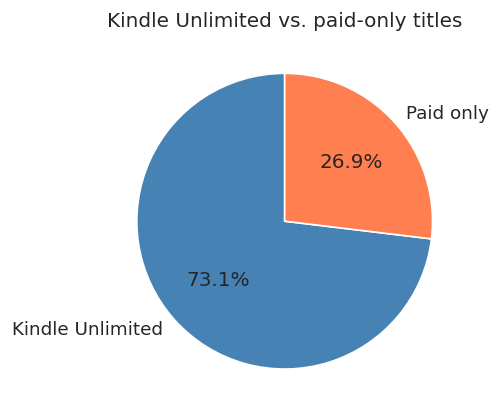

In [9]:
# Kindle Unlimited — free vs paid book share
if 'isKindleUnlimited' in kindle_data.columns:
    ku_counts = kindle_data['isKindleUnlimited'].value_counts()
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.pie(ku_counts, labels=['Kindle Unlimited','Paid only'],
           autopct='%1.1f%%', colors=['steelblue','coral'], startangle=90)
    ax.set_title('Kindle Unlimited vs. paid-only titles')
    plt.show()

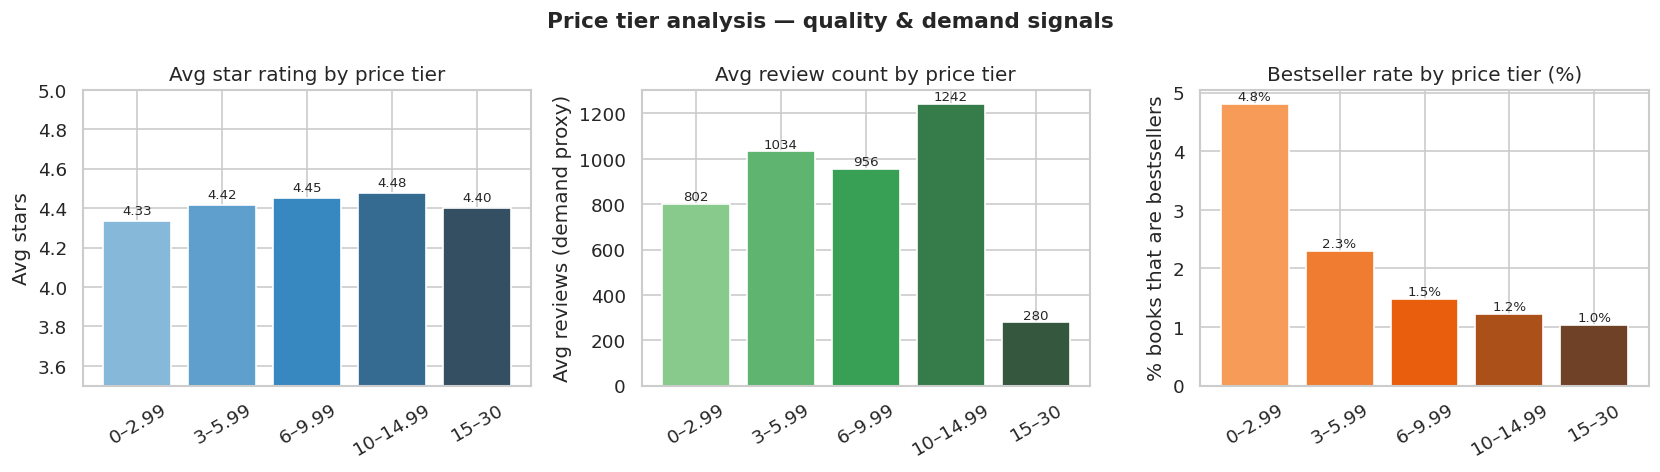

price_tier  avg_stars  avg_reviews  book_count  pct_bestseller
  $0–$2.99   4.334932   802.203922        9945        4.806435
  $3–$5.99   4.416332  1033.705148       27217        2.296359
  $6–$9.99   4.449676   956.172672       35802        1.477571
$10–$14.99   4.477797  1241.995548       27181        1.225120
   $15–$30   4.401083   280.259883       15507        1.031792



---
### Procurement Insight
The **$10–$14.99** tier attracts the highest average review volume (1242 reviews/book),
suggesting this is where reader demand is most concentrated. Books in this range are most likely
to have an established audience before an indie seller stocks them — lower procurement risk.
Cross-reference this with your local customer price sensitivity when building your buy list.


In [10]:
# Sweet Spot Pricing
paid = kindle_data[(kindle_data['price'] > 0) & (kindle_data['price'] <= 30)].copy()

bins   = [0, 2.99, 5.99, 9.99, 14.99, 30]
labels = ['$0–$2.99', '$3–$5.99', '$6–$9.99', '$10–$14.99', '$15–$30']
paid['price_tier'] = pd.cut(paid['price'], bins=bins, labels=labels)

tier_stats = paid.groupby('price_tier', observed=True).agg(
    avg_stars      = ('stars', 'mean'),
    avg_reviews    = ('reviews', 'mean'),
    book_count     = ('title', 'count'),
    pct_bestseller = ('isBestSeller', 'mean')
).reset_index()
tier_stats['pct_bestseller'] *= 100

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Price tier analysis — quality & demand signals', fontsize=13, fontweight='bold')

bars = axes[0].bar(tier_stats['price_tier'], tier_stats['avg_stars'],
                   color=sns.color_palette('Blues_d', len(tier_stats)))
axes[0].set_title('Avg star rating by price tier')
axes[0].set_ylabel('Avg stars')
axes[0].set_ylim(3.5, 5.0)
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, tier_stats['avg_stars']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=8)

bars2 = axes[1].bar(tier_stats['price_tier'], tier_stats['avg_reviews'],
                    color=sns.color_palette('Greens_d', len(tier_stats)))
axes[1].set_title('Avg review count by price tier')
axes[1].set_ylabel('Avg reviews (demand proxy)')
axes[1].tick_params(axis='x', rotation=30)
for bar, val in zip(bars2, tier_stats['avg_reviews']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.0f}', ha='center', va='bottom', fontsize=8)

bars3 = axes[2].bar(tier_stats['price_tier'], tier_stats['pct_bestseller'],
                    color=sns.color_palette('Oranges_d', len(tier_stats)))
axes[2].set_title('Bestseller rate by price tier (%)')
axes[2].set_ylabel('% books that are bestsellers')
axes[2].tick_params(axis='x', rotation=30)
for bar, val in zip(bars3, tier_stats['pct_bestseller']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()
print(tier_stats.to_string(index=False))

sweet = tier_stats.loc[tier_stats['avg_reviews'].idxmax()]
display(Markdown(f"""
---
### Procurement Insight
The **{sweet['price_tier']}** tier attracts the highest average review volume ({sweet['avg_reviews']:.0f} reviews/book),
suggesting this is where reader demand is most concentrated. Books in this range are most likely
to have an established audience before an indie seller stocks them — lower procurement risk.
Cross-reference this with your local customer price sensitivity when building your buy list.
"""))

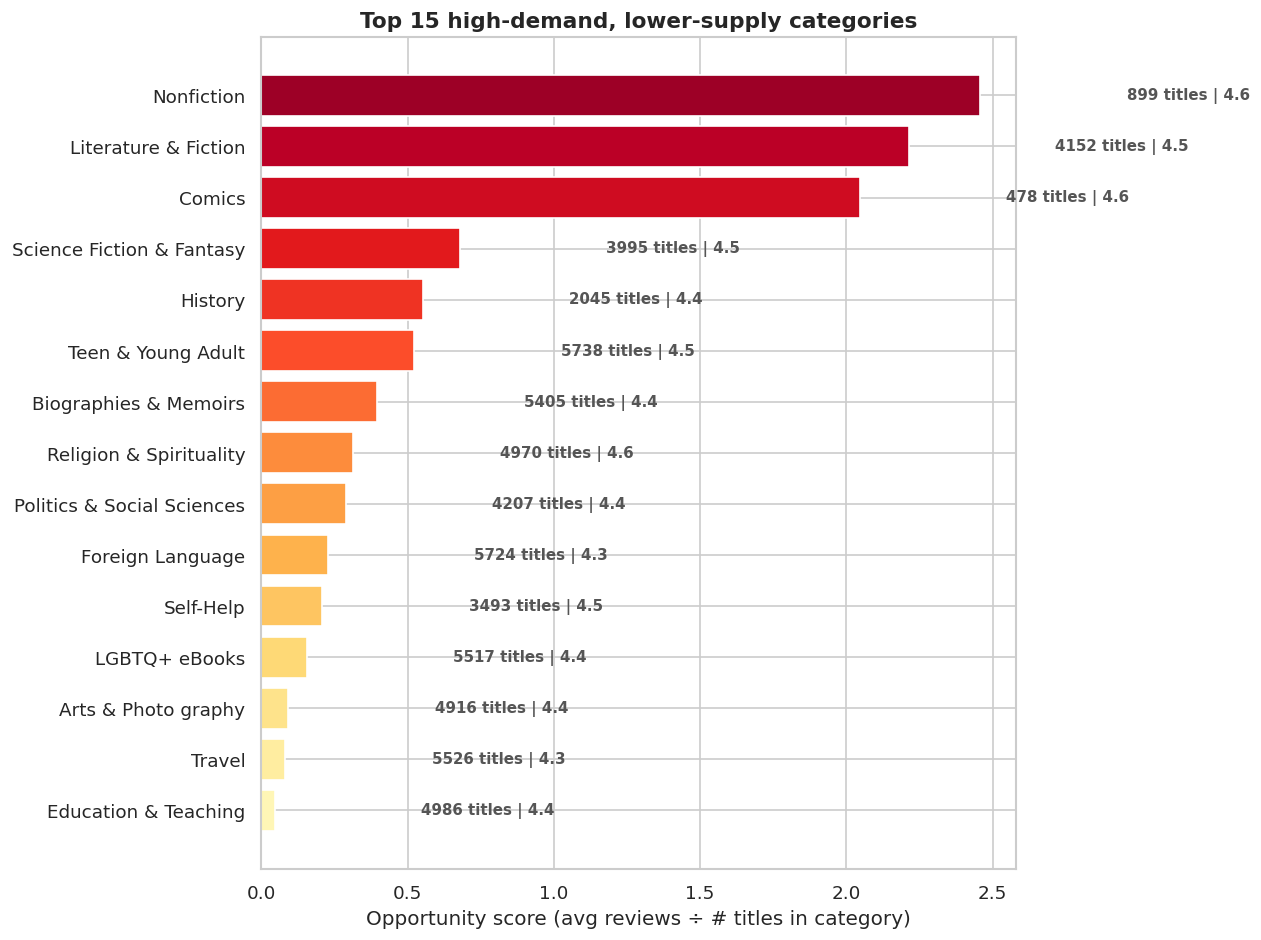

Top 10 opportunity categories:
             category_name  book_count  avg_reviews  avg_stars  median_price  opportunity_score
                Nonfiction         899  2209.286986   4.558732         10.99           2.457494
      Literature & Fiction        4152  9189.571291   4.470641          5.99           2.213288
                    Comics         478   978.213389   4.579289          9.99           2.046472
 Science Fiction & Fantasy        3995  2709.807760   4.535219          4.99           0.678300
                   History        2045  1131.547677   4.435159         10.49           0.553324
        Teen & Young Adult        5738  3004.275532   4.525061          6.99           0.523575
     Biographies & Memoirs        5405  2145.455874   4.441887         11.99           0.396939
   Religion & Spirituality        4970  1564.542052   4.625634          9.99           0.314797
Politics & Social Sciences        4207  1216.501307   4.446328         12.99           0.289161
         


---
###  Procurement Insight
A high opportunity score means readers are highly engaged (many reviews per title)
but the category isn't flooded with competition. These are "niche but passionate" audiences —
ideal for an indie seller who wants to own a category rather than compete on volume.
Categories near the top of this list are worth stocking selectively with the highest-rated titles.


In [11]:
# High-Demand, Underserved Categories
cat_stats = kindle_data.groupby('category_name').agg(
    book_count   = ('title', 'count'),
    avg_reviews  = ('reviews', 'mean'),
    avg_stars    = ('stars', 'mean'),
    median_price = ('price', 'median'),
).reset_index()

cat_stats = cat_stats[cat_stats['book_count'] >= 30].copy()
cat_stats['opportunity_score'] = cat_stats['avg_reviews'] / cat_stats['book_count']
cat_stats = cat_stats.sort_values('opportunity_score', ascending=False)

top_opportunity = cat_stats.head(15)

fig, ax = plt.subplots(figsize=(11, 8)) # Increased height for better fit
colors = sns.color_palette('YlOrRd', len(top_opportunity))[::-1]
bars = ax.barh(top_opportunity['category_name'], top_opportunity['opportunity_score'], color=colors)
ax.set_xlabel('Opportunity score (avg reviews ÷ # titles in category)')
ax.set_title('Top 15 high-demand, lower-supply categories', fontsize=13, fontweight='bold')
ax.invert_yaxis()

for bar, (_, row) in zip(bars, top_opportunity.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{row['book_count']} titles | {row['avg_stars']:.1f}",
            va='center', fontsize=9, color='#555', fontweight='bold')

plt.tight_layout()
plt.show()

print('Top 10 opportunity categories:')
print(top_opportunity[['category_name','book_count','avg_reviews','avg_stars','median_price','opportunity_score']]
      .head(10).to_string(index=False))

display(Markdown("""
---
###  Procurement Insight
A high opportunity score means readers are highly engaged (many reviews per title)
but the category isn't flooded with competition. These are "niche but passionate" audiences —
ideal for an indie seller who wants to own a category rather than compete on volume.
Categories near the top of this list are worth stocking selectively with the highest-rated titles.
"""))

/tmp/ipykernel_11160/2466737051.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  kindle_data['is_series'] = kindle_data['title'].str.contains(series_pattern, case=False, na=False, regex=True)


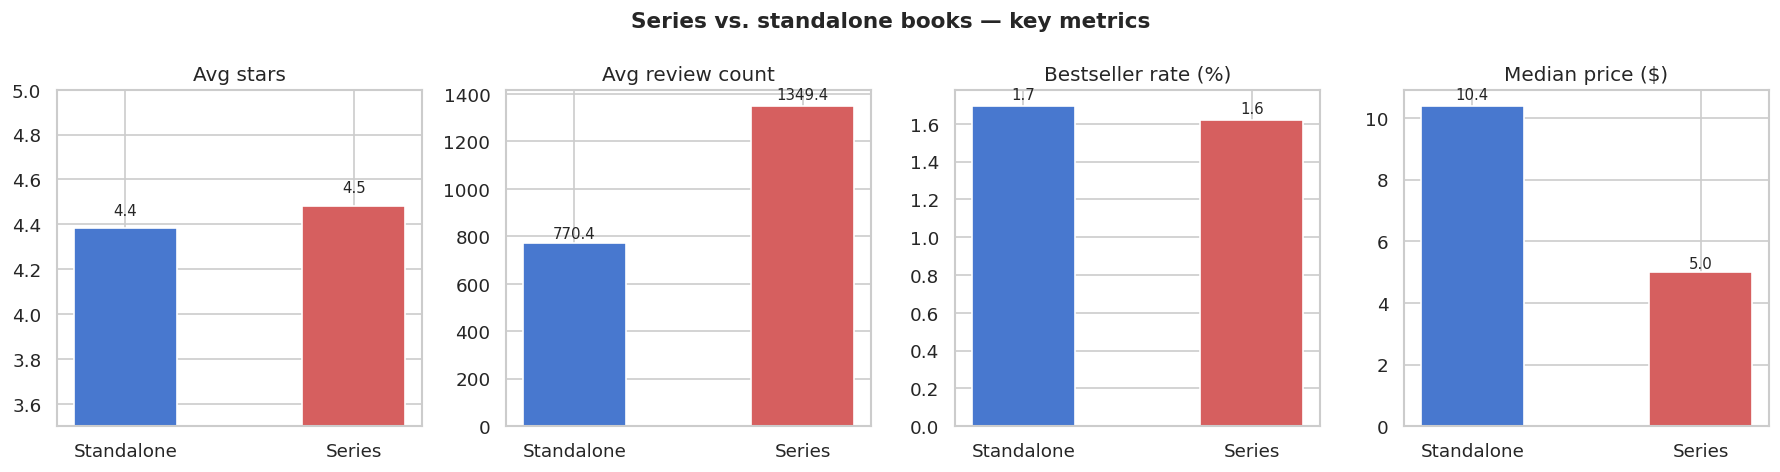

 is_series  count  avg_stars  avg_reviews  median_price  pct_bestseller
Standalone 106215   4.383970   770.409763         10.39        1.694676
    Series  26887   4.483572  1349.440919          4.99        1.621602



---
###  Procurement Insight
Series books average **+75%** more reviews than standalones, which is a strong signal
of repeat engagement — readers who finish book 1 come back for the rest of the series.
For an indie seller, stocking full series (especially volume 1 at an accessible price point)
can drive multiple purchases per customer visit and reduce the cost of customer acquisition.
Prioritize series where book 1 has strong standalone ratings — it lowers the risk of
stocking books 2–5 before customers have committed to the series.


In [12]:
# Series vs. Standalone
import re

series_pattern = r'(book\s*\d+|#\d+|part\s*\d+|vol\.?\s*\d+|volume\s*\d+|\(.*#\d+\))'
kindle_data['is_series'] = kindle_data['title'].str.contains(series_pattern, case=False, na=False, regex=True)

comparison = kindle_data.groupby('is_series').agg(
    count          = ('title', 'count'),
    avg_stars      = ('stars', 'mean'),
    avg_reviews    = ('reviews', 'mean'),
    median_price   = ('price', 'median'),
    pct_bestseller = ('isBestSeller', 'mean'),
).reset_index()
comparison['is_series'] = comparison['is_series'].map({True: 'Series', False: 'Standalone'})
comparison['pct_bestseller'] *= 100

metrics    = ['avg_stars', 'avg_reviews', 'pct_bestseller', 'median_price']
met_labels = ['Avg stars', 'Avg review count', 'Bestseller rate (%)', 'Median price ($)']

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
fig.suptitle('Series vs. standalone books — key metrics', fontsize=13, fontweight='bold')

colors = ['#4878CF', '#D65F5F']
for ax, metric, label in zip(axes, metrics, met_labels):
    bars = ax.bar(comparison['is_series'], comparison[metric], color=colors, width=0.45)
    ax.set_title(label)
    for bar, val in zip(bars, comparison[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.1f}', ha='center', va='bottom', fontsize=9)
    if metric == 'avg_stars':
        ax.set_ylim(3.5, 5.0)

plt.tight_layout()
plt.show()
print(comparison.to_string(index=False))

series_reviews     = comparison.loc[comparison['is_series']=='Series', 'avg_reviews'].values[0]
standalone_reviews = comparison.loc[comparison['is_series']=='Standalone', 'avg_reviews'].values[0]
lift = ((series_reviews - standalone_reviews) / standalone_reviews) * 100

display(Markdown(f"""
---
###  Procurement Insight
Series books average **{lift:+.0f}%** more reviews than standalones, which is a strong signal
of repeat engagement — readers who finish book 1 come back for the rest of the series.
For an indie seller, stocking full series (especially volume 1 at an accessible price point)
can drive multiple purchases per customer visit and reduce the cost of customer acquisition.
Prioritize series where book 1 has strong standalone ratings — it lowers the risk of
stocking books 2–5 before customers have committed to the series.
"""))

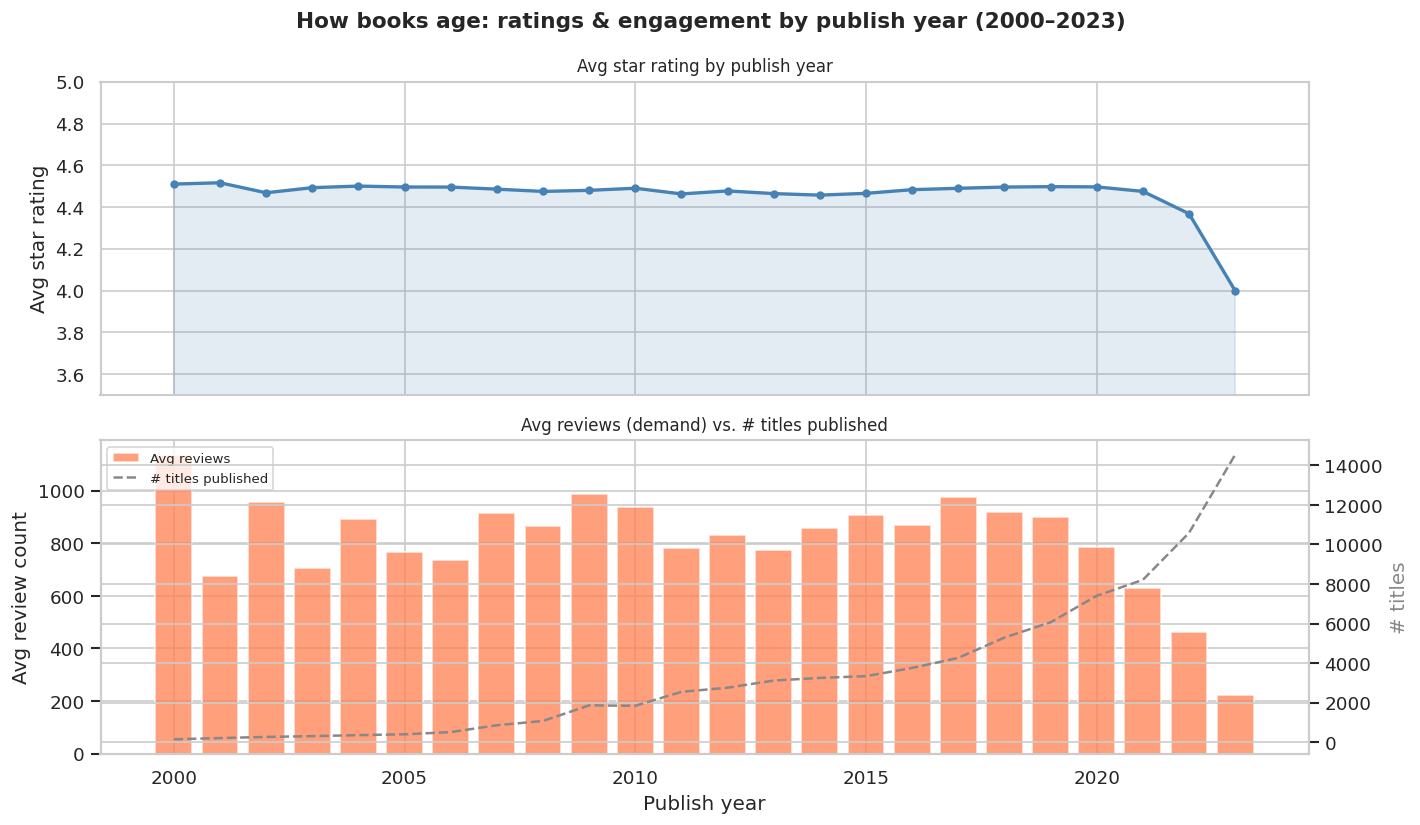


---
### 💡 Procurement Insight
Books published around **2000** show the strongest combination of
high ratings and accumulated reader engagement — meaning they've had time to build an audience
and weed out weak titles, but aren't so old they've lost relevance.

This is the case for investing in **backlist titles**: they're fully reviewed, discounted by
publishers, and often carry less return risk than new releases. A mixed strategy —
~60% proven backlist + ~40% new releases — balances sell-through certainty with
the discovery excitement that drives foot traffic.


In [13]:
# Publish Date Recency vs. Ratings
kindle_data['pub_year'] = pd.to_datetime(kindle_data['publishedDate'], errors='coerce').dt.year
dated = kindle_data[(kindle_data['pub_year'] >= 2000) & (kindle_data['pub_year'] <= 2023)].copy()

year_stats = dated.groupby('pub_year').agg(
    avg_stars      = ('stars', 'mean'),
    avg_reviews    = ('reviews', 'mean'),
    book_count     = ('title', 'count'),
    pct_bestseller = ('isBestSeller', 'mean'),
).reset_index()
year_stats['pct_bestseller'] *= 100

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.suptitle('How books age: ratings & engagement by publish year (2000–2023)',
             fontsize=13, fontweight='bold')

axes[0].plot(year_stats['pub_year'], year_stats['avg_stars'],
             color='steelblue', linewidth=2, marker='o', markersize=4)
axes[0].fill_between(year_stats['pub_year'], year_stats['avg_stars'],
                     alpha=0.15, color='steelblue')
axes[0].set_ylabel('Avg star rating')
axes[0].set_ylim(3.5, 5.0)
axes[0].set_title('Avg star rating by publish year', fontsize=10)

ax2 = axes[1]
ax2.bar(year_stats['pub_year'], year_stats['avg_reviews'],
        color='coral', alpha=0.75, label='Avg reviews')
ax2b = ax2.twinx()
ax2b.plot(year_stats['pub_year'], year_stats['book_count'],
          color='#888', linewidth=1.5, linestyle='--', label='# titles published')
ax2.set_ylabel('Avg review count')
ax2b.set_ylabel('# titles', color='#888')
ax2.set_xlabel('Publish year')
ax2.set_title('Avg reviews (demand) vs. # titles published', fontsize=10)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

year_stats['value_ratio'] = year_stats['avg_stars'] * np.log1p(year_stats['avg_reviews'])
best_era = year_stats.sort_values('value_ratio', ascending=False).iloc[0]

display(Markdown(f"""
---
### 💡 Procurement Insight
Books published around **{int(best_era['pub_year'])}** show the strongest combination of
high ratings and accumulated reader engagement — meaning they've had time to build an audience
and weed out weak titles, but aren't so old they've lost relevance.

This is the case for investing in **backlist titles**: they're fully reviewed, discounted by
publishers, and often carry less return risk than new releases. A mixed strategy —
~60% proven backlist + ~40% new releases — balances sell-through certainty with
the discovery excitement that drives foot traffic.
"""))

---
## 🌐 Feature 1 — Market Trend Explorer
**User input:** a category name + optional price range  
**Output:** 3 charts (price distribution, star distribution, bestseller rate) + an AI-written market brief

In [14]:
# Helper: build stats dict for a filtered subset
def build_category_stats(subset: pd.DataFrame, category: str) -> dict:
    """Compute summary statistics for a filtered category slice."""
    paid = subset[subset['price'] > 0]
    return {
        'category':        category,
        'total_books':     len(subset),
        'avg_price':       round(paid['price'].mean(), 2) if len(paid) else 0,
        'median_price':    round(paid['price'].median(), 2) if len(paid) else 0,
        'avg_stars':       round(subset['stars'].mean(), 2),
        'avg_reviews':     round(subset['reviews'].mean(), 0),
        'pct_bestseller':  round(subset['isBestSeller'].mean() * 100, 1) if 'isBestSeller' in subset else 0,
        'pct_ku':          round(subset['iskindleunlimited'].mean() * 100, 1) if 'iskindleunlimited' in subset else 0,
        'pct_editors_pick':round(subset['isEditorsPick'].mean() * 100, 1) if 'isEditorsPick' in subset else 0,
    }


# Helper: plot three charts side by side
def plot_category_charts(subset: pd.DataFrame, category: str):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(f'Market snapshot: {category}', fontsize=13, fontweight='bold')

    # Chart 1 — price distribution
    paid = subset[(subset['price'] > 0) & (subset['price'] < 30)]
    axes[0].hist(paid['price'], bins=25, color='steelblue', edgecolor='white')
    axes[0].set_title('Price distribution')
    axes[0].set_xlabel('Price ($)')
    axes[0].set_ylabel('Books')

    # Chart 2 — star rating distribution
    axes[1].hist(subset['stars'].dropna(), bins=20, color='coral', edgecolor='white')
    axes[1].set_title('Star ratings')
    axes[1].set_xlabel('Stars')

    # Chart 3 — badge breakdown
    badge_cols = ['isBestSeller', 'isEditorsPick', 'isGoodReadsChoice']
    badge_cols = [c for c in badge_cols if c in subset.columns]
    badge_pcts = [subset[c].mean() * 100 for c in badge_cols]
    badge_labels = [c.replace('is', '') for c in badge_cols]
    axes[2].bar(badge_labels, badge_pcts, color=['#4878CF','#6ACC65','#D65F5F'])
    axes[2].set_title('% books with each badge')
    axes[2].set_ylabel('Percent (%)')
    axes[2].set_ylim(0, max(badge_pcts or [1]) * 1.4)
    for i, v in enumerate(badge_pcts):
        axes[2].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()


# Helper: call OpenAI for the market brief
def generate_market_brief(stats: dict) -> str:
    prompt = f"""
You are a publishing industry analyst. Write a concise 3-paragraph market brief
(plain prose, no headers, no bullet points) for the following Kindle category data.
Highlight key opportunities, competitive signals, and one recommendation for an
independent bookseller who is deciding what genres and titles to carry.

Data:
{json.dumps(stats, indent=2)}
""".strip()

    response = client.chat.completions.create(
        model='gpt-4o',
        messages=[{'role': 'user', 'content': prompt}],
        temperature=0.7,
        max_tokens=400,
    )
    return response.choices[0].message.content


print('✅ Feature 1 helpers defined')

✅ Feature 1 helpers defined


Available categories (top 20):
category_name
Mystery, Thriller & Suspense    6272
Engineering & Transportation    6162
Science & Math                  5955
Parenting & Relationships       5901
Children's eBooks               5747
Teen & Young Adult              5738
Foreign Language                5724
Travel                          5526
LGBTQ+ eBooks                   5517
Computers & Technology          5504
Crafts, Hobbies & Home          5502
Biographies & Memoirs           5405
Cookbooks, Food & Wine          5333
Law                             5027
Education & Teaching            4986
Religion & Spirituality         4970
Arts & Photo graphy             4916
Politics & Social Sciences      4207
Literature & Fiction            4152
Humor & Entertainment           4095

Enter a category name (or partial match): Teen
Min price (press Enter to skip): 5
Max price (press Enter to skip): 15

 Found 3,361 books matching "Teen"


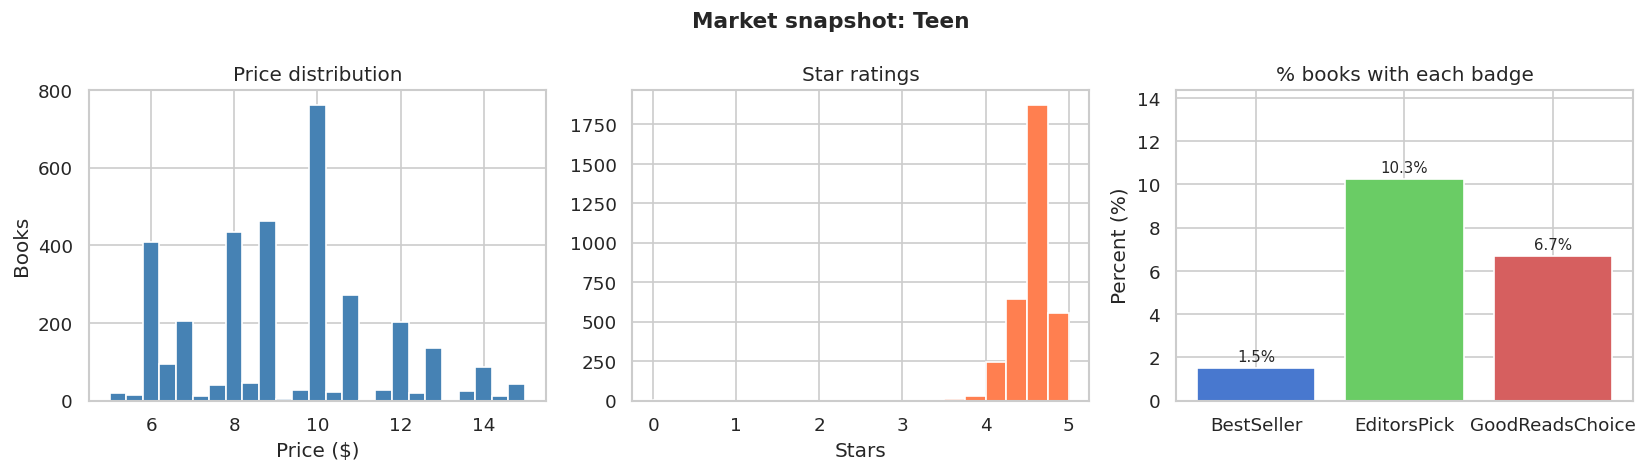


 Summary stats:
  category              : Teen
  total_books           : 3361
  avg_price             : 9.28
  median_price          : 8.99
  avg_stars             : 4.54
  avg_reviews           : 3610.0
  pct_bestseller        : 1.5
  pct_ku                : 0
  pct_editors_pick      : 10.3

 Generating AI market brief...


### Market Brief: Teen

The Teen category in the Kindle marketplace presents a robust and consistently appealing segment, with a total of 3,361 books available. This category is marked by an impressive average rating of 4.54 stars and an average of 3,610 reviews per book, indicating strong reader satisfaction and engagement. The average price sits at $9.28, close to the median price of $8.99, suggesting a relatively narrow price range that maintains accessibility for the target demographic, likely contributing to its stable performance. Notably, only 1.5% of these titles are bestsellers, implying a competitive landscape where gaining bestseller status is challenging but potentially rewarding.

A particularly striking feature of this category is that 10.3% of the titles are designated as Editor’s Picks, a significant proportion that underscores the value of critical acclaim and professional endorsement in this market. The absence of any titles available through Kindle Unlimited (KU) suggests a strategic opportunity for differentiation, as booksellers could consider targeting this gap by offering exclusivity or unique value propositions. The high percentage of Editor’s Picks also suggests that quality and curated selections are highly valued, and there is an opportunity for independent booksellers to emphasize well-reviewed, critically acclaimed titles to capture discerning teen readers and their guardians.

For an independent bookseller, focusing on unique and highly curated selections within the Teen category could be advantageous. Given the high average ratings and reviews, investing in critically acclaimed or Editor’s Pick titles could help in attracting a dedicated readership. Additionally, exploring exclusive offerings or unique marketing strategies could help differentiate from competitors, especially since none of the titles are part of Kindle Unlimited. By highlighting critically endorsed titles and offering personalized recommendations, independent booksellers can carve out a niche that appeals to quality-seeking readers and parents looking for trusted content for teens.

In [15]:
# ── Feature 1: Run it ────────────────────────────────────────────

# Show available categories
print('Available categories (top 20):')
print(kindle_data['category_name'].value_counts().head(20).to_string())
print()

# ── USER INPUT ───────────────────────────────────────────────────
user_category  = input('Enter a category name (or partial match): ').strip()
user_min_price = input('Min price (press Enter to skip): ').strip()
user_max_price = input('Max price (press Enter to skip): ').strip()
# ─────────────────────────────────────────────────────────────────

# Filter
mask = kindle_data['category_name'].str.contains(user_category, case=False, na=False)
subset = kindle_data[mask].copy()

if user_min_price:
    subset = subset[subset['price'] >= float(user_min_price)]
if user_max_price:
    subset = subset[subset['price'] <= float(user_max_price)]

if subset.empty:
    print(f'No books found for "{user_category}". Try a broader term.')
else:
    print(f'\n Found {len(subset):,} books matching "{user_category}"')

    stats = build_category_stats(subset, user_category)
    plot_category_charts(subset, user_category)

    print('\n Summary stats:')
    for k, v in stats.items():
        print(f'  {k:22s}: {v}')

    print('\n Generating AI market brief...')
    brief = generate_market_brief(stats)
    # Ensure proper paragraph breaks for Markdown rendering
    import re
    formatted_brief = re.sub(r'\n+', '\n\n', brief).strip()
    display(Markdown(f'### Market Brief: {user_category}\n\n{formatted_brief}'))

---
## 🔎 Feature 2 — Smart Book Finder
**User input:** a genre/keyword + optional max price  
**Output:** top 5 ranked books from the dataset, enriched with Google Books live data + an AI recommendation blurb

In [16]:
# ── Helper: query Google Books API for a single title ────────────
def fetch_google_books(title: str, author: str = '') -> dict:
    """Returns description, pageCount, thumbnail URL from Google Books."""
    query = f'{title} {author}'.strip()
    params = {'q': query, 'maxResults': 1}
    if GOOGLE_API_KEY:
        params['key'] = GOOGLE_API_KEY

    try:
        r = requests.get('https://www.googleapis.com/books/v1/volumes',
                         params=params, timeout=5)
        r.raise_for_status()
        items = r.json().get('items', [])
        if not items:
            return {}
        info = items[0]['volumeInfo']
        return {
            'gb_description': info.get('description', '')[:600],   # cap length
            'gb_page_count':  info.get('pageCount'),
            'gb_publisher':   info.get('publisher', ''),
            'gb_thumbnail':   info.get('imageLinks', {}).get('thumbnail', ''),
            'gb_categories':  info.get('categories', []),
        }
    except Exception as e:
        print(f'  Google Books lookup failed: {e}')
        return {}


# ── Helper: AI recommendation blurb ─────────────────────────────
def generate_recommendation_blurb(book_row: dict, gb_data: dict) -> str:
    context = {
        'title':            book_row.get('title', ''),
        'author':           book_row.get('author', ''),
        'category':         book_row.get('category_name', ''),
        'price':            book_row.get('price'),
        'stars':            book_row.get('stars'),
        'reviews':          book_row.get('reviews'),
        'kindle_unlimited': book_row.get('iskindleunlimited', False),
        'is_bestseller':    book_row.get('isBestSeller', False),
        'google_description': gb_data.get('gb_description', ''),
        'page_count':       gb_data.get('gb_page_count'),
    }

    prompt = f"""
You are a friendly book recommender. Using the data below, write a 3-sentence
"why you'd love this" blurb that highlights what makes the book stand out.
Keep it warm, specific, and avoid generic phrases like "a must-read".

Book data:
{json.dumps(context, indent=2)}
""".strip()

    response = client.chat.completions.create(
        model='gpt-4o',
        messages=[{'role': 'user', 'content': prompt}],
        temperature=0.75,
        max_tokens=150,
    )
    return response.choices[0].message.content


# ── Helper: display a book card in the notebook ──────────────────
def display_book_card(rank: int, row: pd.Series, gb_data: dict, blurb: str):
    thumbnail = gb_data.get('gb_thumbnail', '')
    ku_badge  = 'Kindle Unlimited' if row.get('iskindleunlimited') else ''
    bs_badge  = 'Bestseller' if row.get('isBestSeller') else ''
    ep_badge  = 'Editor\'s Pick' if row.get('isEditorsPick') else ''
    badges    = '  '.join(b for b in [ku_badge, bs_badge, ep_badge] if b)

    price_str = f'${row["price"]:.2f}' if pd.notna(row.get('price')) and row['price'] > 0 else 'Free'
    stars_str = f'{row["stars"]:.1f}' if pd.notna(row.get('stars')) else ''
    rev_str   = f'({int(row["reviews"]):,} reviews)' if pd.notna(row.get('reviews')) else ''

    displayed_category = ", ".join(gb_data.get('gb_categories')) if gb_data.get('gb_categories') else row.get('category_name', '')

    md = f"""
---
### #{rank}  {row['title']}
**Author:** {row.get('author', 'Unknown')}
**Category:** {displayed_category}
**Price:** {price_str}  {stars_str} {rev_str}
{badges}

*{blurb}*
"""
    display(Markdown(md))
    if thumbnail:
        display(Image(url=thumbnail, width=80))


print('✅ Feature 2 helpers defined')

✅ Feature 2 helpers defined


In [17]:
# ── Feature 2: Run it ────────────────────────────────────────────

# ── USER INPUT ───────────────────────────────────────────────────
user_keyword   = input('Search keyword or genre (e.g. "mystery thriller"): ').strip()
user_max_price = input('Max price in $ (press Enter to skip): ').strip()
user_top_n     = int(input('How many results to show? (1-10, default 5): ').strip() or 5)
# ─────────────────────────────────────────────────────────────────

# Search: match keyword in title or category
title_match    = kindle_data['title'].str.contains(user_keyword, case=False, na=False)
category_match = kindle_data['category_name'].str.contains(user_keyword, case=False, na=False)
results = kindle_data[title_match | category_match].copy()

if user_max_price:
    results = results[results['price'] <= float(user_max_price)]

if results.empty:
    print(f'No results for "{user_keyword}". Try a different keyword.')
else:
    # Rank by composite score (stars × log(reviews))
    results = results.sort_values('score', ascending=False).head(user_top_n)
    print(f'\n Top {len(results)} results for "{user_keyword}"\n')

    for rank, (_, row) in enumerate(results.iterrows(), start=1):
        print(f'  Fetching data for #{rank}: {row["title"][:60]}...')
        gb_data = fetch_google_books(row['title'], row.get('author', ''))
        blurb   = generate_recommendation_blurb(row.to_dict(), gb_data)
        display_book_card(rank, row, gb_data, blurb)

Search keyword or genre (e.g. "mystery thriller"): mystery
Max price in $ (press Enter to skip): 20
How many results to show? (1-10, default 5): 5

 Top 5 results for "mystery"

  Fetching data for #1: The Secret Wife: A captivating story of romance, passion and...



---
### #1  The Secret Wife: A captivating story of romance, passion and mystery: Love. Guilt. Heartbreak.
**Author:** Gill Paul
**Category:** Fiction
**Price:** Free  4.4 (50,428 reviews)


*If you have a penchant for intricate tales of love interwoven with mystery, "The Secret Wife" by Gill Paul promises to captivate your heart and mind. This beautifully crafted narrative delves into a world of deep emotions and historical intrigue, exploring themes of love, guilt, and heartbreak that will keep you turning pages. With its compelling storytelling and richly developed characters, this novel offers a poignant journey that lingers long after you've read the last page.*


  Fetching data for #2: Girl in the Box: A Paranormal Mystery Thriller Series (Books...



---
### #2  Girl in the Box: A Paranormal Mystery Thriller Series (Books 1-3 Box Set)
**Author:** Robert J. Crane
**Category:** Paranormal fiction
**Price:** $2.99  4.4 (33,712 reviews)


*If you're captivated by tales of self-discovery and supernatural abilities, the "Girl in the Box" series by Robert J. Crane offers a thrilling escape into a world where a teenage girl uncovers extraordinary powers. With over 33,000 reviews and a strong 4.4-star rating, this collection invites you to join a heroine who must navigate the treacherous waters between newfound strength and the forces eager to control her. Delve into these first three books and experience a blend of mystery, action, and emotional depth that will keep you turning the pages late into the night.*


  Fetching data for #3: The Long Way Home: A Chief Inspector Gamache Novel (A Chief ...



---
### #3  The Long Way Home: A Chief Inspector Gamache Novel (A Chief Inspector Gamache Mystery Book 10)
**Author:** Louise Penny
**Category:** Fiction
**Price:** $11.99  4.4 (24,945 reviews)
Editor's Pick

*If you cherish mysteries that intertwine intricate plots with deep emotional currents, "The Long Way Home" by Louise Penny is a journey you'll savor. Set in the rich tapestry of Chief Inspector Armand Gamache’s world, this novel brilliantly balances facts with feelings as the beloved inspector embarks on a poignant quest to find Clara Morrow’s missing husband. Louise Penny’s masterful storytelling will keep you guessing, while her beautifully drawn characters and heartfelt narrative invite you to explore the complexities of human relationships and the elusive nature of truth.*


  Fetching data for #4: The Paradigm: The Ancient Blueprint That Holds the Mystery o...



---
### #4  The Paradigm: The Ancient Blueprint That Holds the Mystery of Our Times
**Author:** Jonathan Cahn
**Category:** Religion & Spirituality
**Price:** $13.10  4.7 (9,512 reviews)


*Dive into "The Paradigm: The Ancient Blueprint That Holds the Mystery of Our Times" by Jonathan Cahn, where history and prophecy intertwine in a tapestry that will captivate your imagination and challenge your perspective. With an impressive 4.7-star rating from over 9,500 readers, this book offers a thought-provoking journey through the echoes of ancient wisdom and its uncanny relevance to today's world. Perfect for those who love to explore the depths of spirituality and uncover hidden connections, this compelling narrative will leave you pondering the mysteries of our time long after you turn the last page.*


  Fetching data for #5: The Mystery of the Shemitah Updated Edition: The 3,000-Year-...



---
### #5  The Mystery of the Shemitah Updated Edition: The 3,000-Year-Old Mystery That Holds the Secret of America's Future, the World's Future...and Your Future!
**Author:** Jonathan Cahn
**Category:** Religion
**Price:** $12.19  4.7 (7,810 reviews)


*Dive into "The Mystery of the Shemitah Updated Edition" by Jonathan Cahn for a riveting exploration that intertwines ancient biblical prophecy with modern-day events, offering a unique lens through which to view the future of America and the world. With its captivating narrative and meticulously researched insights, this book promises to engage both your intellect and your imagination, sparking profound reflections on the spiritual and historical forces shaping our lives. Ideal for those who enjoy thought-provoking reads that challenge conventional perspectives, this work stands out as an illuminating journey into the mysteries of time and prophecy.*


---
## ✍️ Feature 3 — AI Book Pitch Generator
**User input:** a book title (or partial title) from the dataset  
**Output:** an AI-written marketing pitch — back-cover blurb + social media hook — grounded in real sales data

In [18]:
# ── Feature 3: AI Book Pitch Generator (updated) ─────────────────

# ── Helper: build the full context package for a book ────────────
def build_book_context(row, gb_data):
    return {
        'title':              row.get('title', ''),
        'author':             row.get('author', ''),
        'category':           row.get('category_name', ''),
        'price':              row.get('price'),
        'stars':              row.get('stars'),
        'review_count':       int(row['reviews']) if pd.notna(row.get('reviews')) else None,
        'kindle_unlimited':   bool(row.get('iskindleunlimited', False)),
        'is_bestseller':      bool(row.get('isBestSeller', False)),
        'is_editors_pick':    bool(row.get('isEditorsPick', False)),
        'is_goodreads':       bool(row.get('isGoodReadsChoice', False)),
        'published_date':     str(row.get('publishedDate', '')),
        'google_description': gb_data.get('gb_description', ''),
        'page_count':         gb_data.get('gb_page_count'),
        'publisher':          gb_data.get('gb_publisher', ''),
    }


# ── Helper: generate the pitch ───────────────────────────────────
def generate_pitch(context, pitch_style='standard'):
    badges = []
    if context.get('is_bestseller'):   badges.append("Amazon Bestseller")
    if context.get('is_editors_pick'): badges.append("Editor's Pick")
    if context.get('is_goodreads'):    badges.append("Goodreads Choice")
    badge_str = ', '.join(badges) if badges else 'No special badges'

    style_instructions = {
        'standard': (
            'Write a compelling back-cover blurb (2 short paragraphs) followed by '
            'a single punchy one-sentence hook prefixed with "Hook: ".'
        ),
        'indie': (
            "Write a first-person pitch from the author's perspective for a newsletter "
            '(2 paragraphs) plus a one-sentence tweet-style hook prefixed with "Hook: ".'
        ),
        'gift': (
            'Write a gift recommendation blurb (2 short paragraphs) explaining who would '
            'love this book and why, then a one-sentence hook prefixed with "Hook: ".'
        ),
        'social': (
            'Write a social media caption for an independent bookstore promoting this book. '
            'Format your response in exactly three parts:\n'
            '  Caption: 3–4 sentences, warm and conversational — written as if a bookseller '
            'who genuinely loves this book is talking directly to their local community. '
            'Reference specific details from the book data (ratings, category, badges) '
            'naturally. No generic phrases like "a must-read" or "page-turner".\n'
            '  Hashtags: 5–8 relevant hashtags on one line, prefixed with "Hashtags: ". '
            'Mix book-specific tags, genre tags, and bookstore community tags '
            '(e.g. #IndieBookstore #Bookstagram #ShopLocal).\n'
            '  Alt text: one sentence describing the post for accessibility, '
            'prefixed with "Alt text: ". Write it as if describing a photo of the book '
            'cover displayed in a cozy bookstore setting.'
        ),
    }

    prompt = f"""
You are a skilled book marketing copywriter.
{style_instructions.get(pitch_style, style_instructions['standard'])}

Ground your copy in the real data provided — mention specific ratings, badges, or
audience cues naturally. Keep the tone engaging and specific, never generic.

Badges earned: {badge_str}
Book data:
{json.dumps(context, indent=2)}
""".strip()

    response = client.chat.completions.create(
        model='gpt-4o',
        messages=[{'role': 'user', 'content': prompt}],
        temperature=0.8,
        max_tokens=400,
    )
    return response.choices[0].message.content


# ── Helper: format the social caption output cleanly ─────────────
def format_social_output(raw_text, book_title):
    """Parse and display the three social media sections with clear visual separation."""
    sections = {'caption': '', 'hashtags': '', 'alt_text': ''}

    for line in raw_text.splitlines():
        l = line.strip()
        if l.lower().startswith('caption:'):
            sections['caption'] = l[len('caption:'):].strip()
        elif l.lower().startswith('hashtags:'):
            sections['hashtags'] = l[len('hashtags:'):].strip()
        elif l.lower().startswith('alt text:'):
            sections['alt_text'] = l[len('alt text:'):].strip()

    # If parsing didn't split cleanly, fall back to showing the raw text
    if not any(sections.values()):
        display(Markdown(raw_text))
        return

    display(Markdown(f"""
---
### Social Media Caption — {book_title}

**Caption**
{sections['caption']}

**Hashtags**
{sections['hashtags']}

**Alt text**
*{sections['alt_text']}*
"""))


In [19]:
# ── Run Feature 3 ────────────────────────────────────────────────

user_title = input('Enter a book title (or partial title): ').strip()
print("""
Pitch styles:
  1 — Standard back-cover blurb + hook
  2 — Indie author newsletter pitch
  3 — Gift recommendation
  4 — Social media caption (with hashtags + alt text)
""")
style_choice = input('Choose style (1/2/3/4, default 1): ').strip() or '1'

style_map = {'1': 'standard', '2': 'indie', '3': 'gift', '4': 'social'}
pitch_style = style_map.get(style_choice, 'standard')

# Find the book
matches = kindle_data[kindle_data['title'].str.contains(user_title, case=False, na=False)]

if matches.empty:
    print(f'No book found matching "{user_title}". Try a partial title.')
else:
    if len(matches) > 1:
        print(f'Found {len(matches)} matches — using top result by score:')
        print(matches[['title','author','stars','reviews']].head(5).to_string(index=False))
    book_row = matches.sort_values('score', ascending=False).iloc[0]

    print(f'\n Generating pitch for: "{book_row["title"]}"')
    print(f'   Author: {book_row.get("author","Unknown")}  |  '
          f'Stars: {book_row.get("stars")}  |  Price: ${book_row.get("price")}')

    print('   Fetching Google Books data...')
    gb_data = fetch_google_books(book_row['title'], book_row.get('author', ''))

    context = build_book_context(book_row, gb_data)

    print('   Generating AI pitch...\n')
    pitch = generate_pitch(context, pitch_style)

    if pitch_style == 'social':
        format_social_output(pitch, book_row['title'])
    else:
        display(Markdown(f'---\n###  Marketing Pitch — {book_row["title"]}\n\n{pitch}'))

    if gb_data.get('gb_thumbnail'):
        display(Image(url=gb_data['gb_thumbnail'], width=100))

Enter a book title (or partial title): Lord of the Rings

Pitch styles:
  1 — Standard back-cover blurb + hook
  2 — Indie author newsletter pitch
  3 — Gift recommendation
  4 — Social media caption (with hashtags + alt text)

Choose style (1/2/3/4, default 1): 4
Found 11 matches — using top result by score:
                                                                       title         author  stars  reviews
The Fellowship of the Knits: Lord of the Rings: The Unofficial Knitting Book     Tanis Gray    5.0        0
                                           The Lord Of The Rings: One Volume J.R.R. Tolkien    4.9    11000
   The Fellowship Of The Ring: Being the First Part of The Lord of the Rings J.R.R. Tolkien    4.8    21171
              The Two Towers: Being the Second Part of The Lord of the Rings J.R.R. Tolkien    4.8    12752
       The Return Of The King: Being the Third Part of the Lord of the Rings J.R.R. Tolkien    4.9    10234

 Generating pitch for: "The Fellowship O


---
### Social Media Caption — The Fellowship Of The Ring: Being the First Part of The Lord of the Rings

**Caption**
Step into the rich, imaginative world of Middle-earth with "The Fellowship Of The Ring" by the legendary J.R.R. Tolkien! With a stellar 4.8-star rating and over 21,000 glowing reviews, this classic fantasy tale is a favorite among readers and a true testament to its timeless appeal. Join Frodo, Sam, and their unforgettable fellowship on a journey that will capture your heart and stir your imagination. Swing by our store today to grab your own copy and start your epic adventure!

**Hashtags**
#TheFellowshipOfTheRing #JRRRTolkien #FantasyLiterature #IndieBookstore #Bookstagram #ShopLocal

**Alt text**
*A cozy bookstore display featuring the cover of "The Fellowship Of The Ring" by J.R.R. Tolkien, surrounded by lush green plants and warm wooden shelves.*


---
##  Project Summary

| | Feature 1 | Feature 2 | Feature 3 |
|---|---|---|---|
| **User input** | Category + price range | Keyword + max price | Book title + pitch style |
| **Dataset use** | Aggregate stats + charts | Ranked results by composite score | Per-book metadata + badges |
| **External API** | — | Google Books (description, cover, pages) | Google Books (description, publisher) |
| **AI output** | 3-paragraph market brief | 3-sentence recommendation blurb | Back-cover pitch + social hook |